# 01 — Exploratory Data Analysis

**Goal:** understand the shape of the ratings data before feature engineering / modeling —
rating distribution, user-item matrix sparsity, activity skew, genre mix, and the tag genome.

Data source: `data/raw/` (populated by `src/data_loader.py`, ignored by git).

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

DATA_DIR = '../data/raw'

Matplotlib is building the font cache; this may take a moment.


## Load data

`genome_scores.csv` is large (~435MB); load it last / only when needed.

In [2]:
train = pd.read_csv(f'{DATA_DIR}/train.csv')
test = pd.read_csv(f'{DATA_DIR}/test.csv')
movies = pd.read_csv(f'{DATA_DIR}/movies.csv')
links = pd.read_csv(f'{DATA_DIR}/links.csv')
tags = pd.read_csv(f'{DATA_DIR}/tags.csv')
imdb_data = pd.read_csv(f'{DATA_DIR}/imdb_data.csv')
genome_tags = pd.read_csv(f'{DATA_DIR}/genome_tags.csv')

print('train:', train.shape)
print('test:', test.shape)
print('movies:', movies.shape)
print('links:', links.shape)
print('tags:', tags.shape)
print('imdb_data:', imdb_data.shape)
print('genome_tags:', genome_tags.shape)

train: (10000038, 4)
test: (5000019, 2)
movies: (62423, 3)
links: (62423, 3)
tags: (1093360, 4)
imdb_data: (27278, 6)
genome_tags: (1128, 2)


In [3]:
train.head()

,userId,movieId,rating,timestamp
0,5163,57669,4.0,1518349992
1,106343,5,4.5,1206238739
2,146790,5459,5.0,1076215539
3,106362,32296,2.0,1423042565
4,9041,366,3.0,833375837


In [4]:
train.info()
train.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10000038 entries, 0 to 10000037
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 305.2 MB


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

## 1. Rating distribution

count    1.000004e+07
mean     3.533395e+00
std      1.061124e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


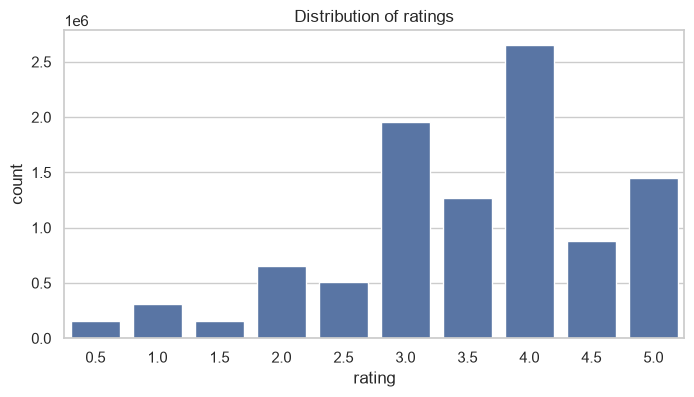

In [5]:
print(train['rating'].describe())

fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(x='rating', data=train, ax=ax, color='#4C72B0')
ax.set_title('Distribution of ratings')
plt.show()

## 2. User-item matrix sparsity & activity skew

In [6]:
n_users = train['userId'].nunique()
n_movies = train['movieId'].nunique()
n_ratings = len(train)
density = n_ratings / (n_users * n_movies)

print(f'Unique users: {n_users:,}')
print(f'Unique movies: {n_movies:,}')
print(f'Ratings: {n_ratings:,}')
print(f'Matrix density: {density:.6%}  (sparsity: {1 - density:.6%})')

Unique users: 162,541
Unique movies: 48,213
Ratings: 10,000,038
Matrix density: 0.127607%  (sparsity: 99.872393%)


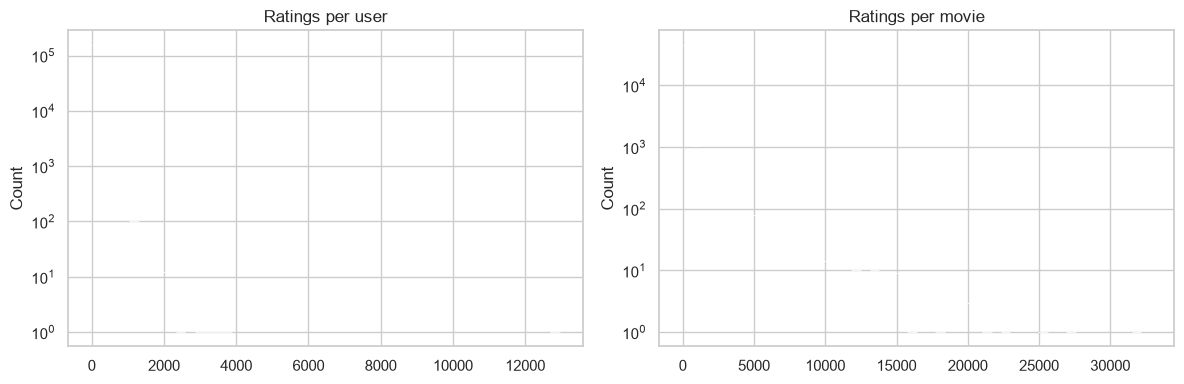

count    162541.000000
mean         61.523173
std         107.410889
min           1.000000
25%          14.000000
50%          28.000000
75%          65.000000
max       12952.000000
dtype: float64
count    48213.000000
mean       207.413727
std       1092.768777
min          1.000000
25%          1.000000
50%          4.000000
75%         26.000000
max      32831.000000
dtype: float64


In [7]:
ratings_per_user = train.groupby('userId').size()
ratings_per_movie = train.groupby('movieId').size()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(ratings_per_user, bins=50, log_scale=(False, True), ax=axes[0])
axes[0].set_title('Ratings per user')
sns.histplot(ratings_per_movie, bins=50, log_scale=(False, True), ax=axes[1])
axes[1].set_title('Ratings per movie')
plt.tight_layout()
plt.show()

print(ratings_per_user.describe())
print(ratings_per_movie.describe())

## 3. Item popularity

In [8]:
movie_stats = (
    train.groupby('movieId')['rating']
    .agg(['count', 'mean'])
    .join(movies.set_index('movieId')['title'])
    .sort_values('count', ascending=False)
)

print('Most-rated movies:')
display(movie_stats.head(15))

print('\nHighest-rated movies (min 100 ratings):')
display(movie_stats[movie_stats['count'] >= 100].sort_values('mean', ascending=False).head(15))

Most-rated movies:


,count,mean,title
movieId,,,
318,32831,4.417624,"Shawshank Redemption, The (1994)"
356,32383,4.047216,Forrest Gump (1994)
296,31697,4.195097,Pulp Fiction (1994)
593,29444,4.144172,"Silence of the Lambs, The (1991)"
2571,29014,4.154253,"Matrix, The (1999)"
260,27560,4.111811,Star Wars: Episode IV - A New Hope (1977)
480,25518,3.684634,Jurassic Park (1993)
527,24004,4.247625,Schindler's List (1993)
110,23722,3.994119,Braveheart (1995)



Highest-rated movies (min 100 ratings):


,count,mean,title
movieId,,,
171011,439,4.517084,Planet Earth II (2016)
159817,674,4.473294,Planet Earth (2006)
171495,116,4.456897,Cosmos
318,32831,4.417624,"Shawshank Redemption, The (1994)"
170705,575,4.399130,Band of Brothers (2001)
142115,216,4.337963,The Blue Planet (2001)
858,20960,4.311355,"Godfather, The (1972)"
100044,132,4.295455,Human Planet (2011)
179135,264,4.291667,Blue Planet II (2017)


## 4. Genre breakdown

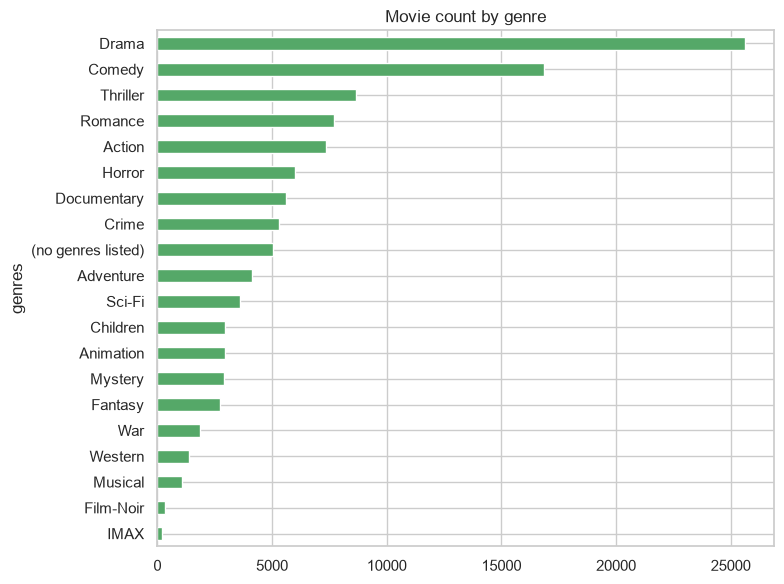

In [9]:
genres_exploded = movies.assign(genres=movies['genres'].str.split('|')).explode('genres')
genre_counts = genres_exploded['genres'].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))
genre_counts.plot(kind='barh', ax=ax, color='#55A868')
ax.invert_yaxis()
ax.set_title('Movie count by genre')
plt.tight_layout()
plt.show()

## 5. Tag genome overview

Loaded separately since `genome_scores.csv` is large.

In [10]:
genome_scores = pd.read_csv(f'{DATA_DIR}/genome_scores.csv')
print('genome_scores:', genome_scores.shape)

avg_relevance = (
    genome_scores.groupby('tagId')['relevance'].mean()
    .sort_values(ascending=False)
    .to_frame()
    .join(genome_tags.set_index('tagId'))
)
avg_relevance.head(15)

genome_scores: (15584448, 3)


,relevance,tag
tagId,,
742,0.724424,original
646,0.541578,mentor
188,0.476752,catastrophe
468,0.475400,great ending
972,0.450228,storytelling
867,0.447721,runaway
302,0.447113,dialogue
452,0.428610,good soundtrack
1104,0.422813,weird


## Next steps

- Decide which signals (genome relevance, genres, IMDb metadata, tags) feed into `src/preprocessing.py`.
- Check `test.csv` user/movie overlap with `train.csv` (cold-start users/movies).
- Baseline: global mean / per-movie mean RMSE, to benchmark later models against.